In [1]:
import os
import pandas as pd
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

In [2]:
def tflog2pandas(path):
    runlog_data = pd.DataFrame()
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    tags = ea.Tags()['scalars']

    for tag in tags:
        event_list = ea.Scalars(tag)
        values = [e.value for e in event_list]
        steps = [e.step for e in event_list]
        tag_df = pd.DataFrame({tag: values, 'step': steps})
        
        if runlog_data.empty:
            runlog_data = tag_df
        else:
            runlog_data = pd.merge(runlog_data, tag_df, on="step", how="outer")

    return runlog_data


In [3]:
log_path = "../src/runs/rl/espov3/run8"
df = tflog2pandas(log_path)
df = df.iloc[::2]  # reward was accidentally logged twice per epoch
df.index = range(len(df))

In [182]:
df

,Components/legal_rate,step,Components/uniqueness_rate,Components/counter_intuitive_rate,Components/counter_intuitive_rate_given_unique,Components/unique_and_counter_intuitive,Components/entropy,Components/piece_counts,Components/dist_inter_fen,Components/dist_intra_fen,...,Components/all_dist,Components/pass_diversity_filtering,Components/move_match_rate,Components/cp_loss,Reward,Loss/Total Loss,Loss/RL Grad Norm,Loss/KL divergence,Loss/Clips,Loss/learning_rate
0,1.0000,0,0.2500,0.2500,0.0,0.0,0.620707,1.000000,15.000000,18.8750,...,0.250000,1.000000,0.437500,0.0,0.02500,-2.980232e-08,1.033839,0.000000e+00,0.0,3.400000e-07
1,1.0000,1,0.2500,0.0625,0.0,0.0,0.657466,1.000000,15.125000,19.5625,...,0.312500,1.000000,0.625000,0.0,0.02500,-2.977414e-08,1.354188,2.818047e-09,0.0,6.700000e-07
2,1.0000,2,0.2500,0.1250,0.0,0.0,0.609185,1.000000,14.875000,19.0625,...,0.250000,1.000000,0.625000,0.0,0.02500,-2.277348e-09,0.989278,2.752497e-06,0.0,1.000000e-06
3,1.0000,3,0.1250,0.2500,0.0,0.0,0.596667,1.000000,14.125000,18.1875,...,0.375000,1.000000,0.375000,0.0,0.01250,2.885606e-07,1.181827,2.699342e-05,0.0,1.000000e-06
4,1.0000,4,0.1875,0.1250,0.0,0.0,0.614508,1.000000,14.500000,19.2500,...,0.375000,1.000000,0.375000,0.0,0.01875,2.701079e-06,1.304937,2.766271e-04,0.0,1.000000e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1625,1.0000,1625,0.3750,0.0000,0.0,0.0,0.582446,0.875000,13.562500,18.3125,...,0.250000,0.875000,0.812500,0.0,0.03750,7.173653e-04,1.363493,7.173541e-02,0.0,1.000000e-06
1626,1.0000,1626,0.1875,0.3125,0.0,0.0,0.630885,0.937500,13.187500,17.0000,...,0.250000,0.937500,0.562500,0.0,0.01875,7.649633e-04,1.655373,7.650284e-02,0.0,1.000000e-06
1627,0.9375,1627,0.1875,0.2500,0.0,0.0,0.688803,0.933333,14.933333,20.6000,...,0.400000,0.933333,0.466667,0.0,-0.11250,2.019902e-03,2.260527,2.019900e-01,0.0,1.000000e-06
1628,1.0000,1628,0.1250,0.2500,0.0,0.0,0.602111,1.000000,13.312500,18.2500,...,0.187500,1.000000,0.375000,0.0,0.01250,6.150623e-04,1.631491,6.150436e-02,0.0,1.000000e-06


In [4]:
def plot_rolling(col: pd.DataFrame, window=100):
    col.rolling(window=window, win_type='gaussian').mean(std=window / 4).plot(title=col.name)

def plot_ema(col, alpha=0.001, start=0):
    col.ewm(alpha=0.001).mean().iloc[start:].plot(title=col.name)

def plot_all(df: pd.DataFrame, *args, window=100, alpha=0.001, start=0, type="rolling"):
    for col in df:
        plt.figure()
        if type == "rolling":
            plot_rolling(df[col], window=window)
        elif type == "ema":
            plot_ema(df[col], alpha=alpha, start=start)
    plt.show()

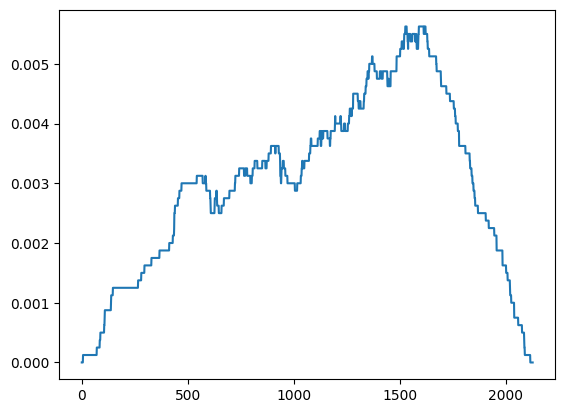

In [ ]:
import numpy as np


plt.plot(np.convolve(df["Components/unique_and_counter_intuitive"].to_numpy(), np.ones(500) / 500))
plt.show()

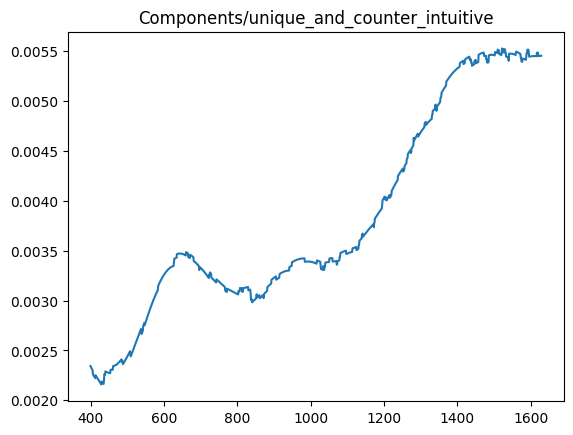

In [9]:
plot_rolling(df["Components/unique_and_counter_intuitive"], 400)

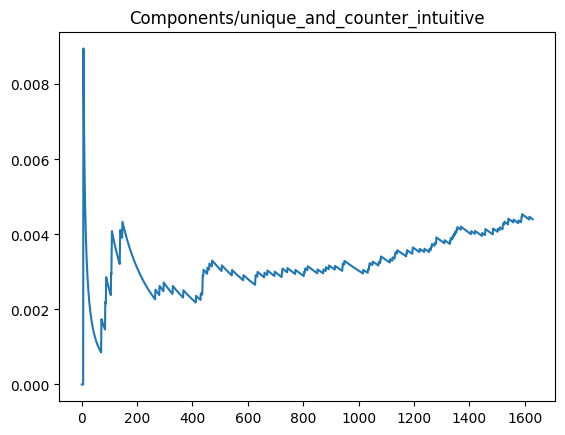

In [ ]:
plot_ema(df["Components/unique_and_counter_intuitive"])

In [239]:
df.columns

Index(['Components/legal_rate', 'step', 'Components/uniqueness_rate',
       'Components/counter_intuitive_rate',
       'Components/counter_intuitive_rate_given_unique',
       'Components/unique_and_counter_intuitive', 'Components/entropy',
       'Components/piece_counts', 'Components/dist_inter_fen',
       'Components/dist_intra_fen', 'Components/dist_inter_pv',
       'Components/dist_intra_pv', 'Components/intra_dist',
       'Components/inter_dist', 'Components/all_dist',
       'Components/pass_diversity_filtering', 'Components/move_match_rate',
       'Components/cp_loss', 'Reward', 'Loss/Total Loss', 'Loss/RL Grad Norm',
       'Loss/KL divergence', 'Loss/Clips', 'Loss/learning_rate'],
      dtype='object')

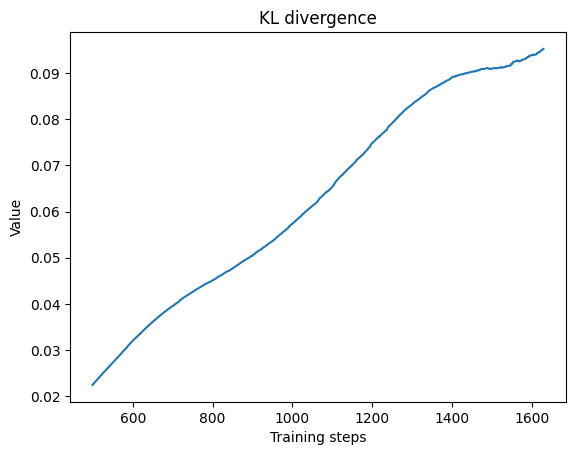

In [275]:
plot_rolling(df["Loss/KL divergence"], window=500)
plt.title("KL divergence")
plt.xlabel("Training steps")
# plt.ylabel("Percentage of positions")
plt.ylabel("Value")
plt.savefig("./slides/figures/kl_divergence.pdf")
plt.show()

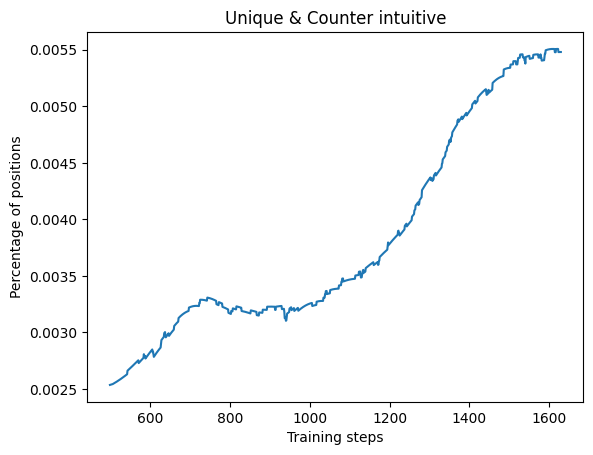

In [238]:
plot_rolling(df["Components/unique_and_counter_intuitive"], window=500)
plt.title("Unique & Counter intuitive")
plt.xlabel("Training steps")
plt.ylabel("Percentage of positions")
plt.savefig("./slides/figures/unique_and_counter_intuitive.pdf")
plt.show()

C:\Users\aatus\AppData\Local\Temp\ipykernel_7948\2233020243.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


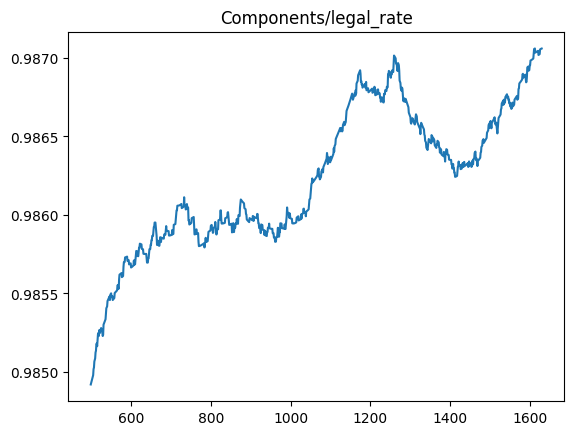

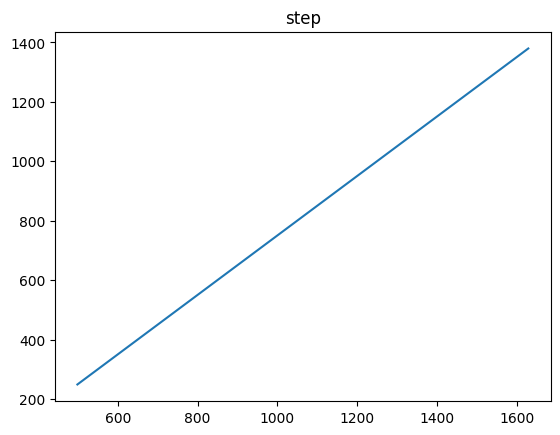

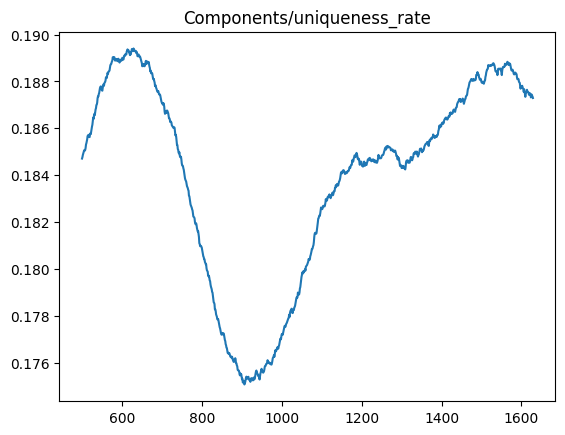

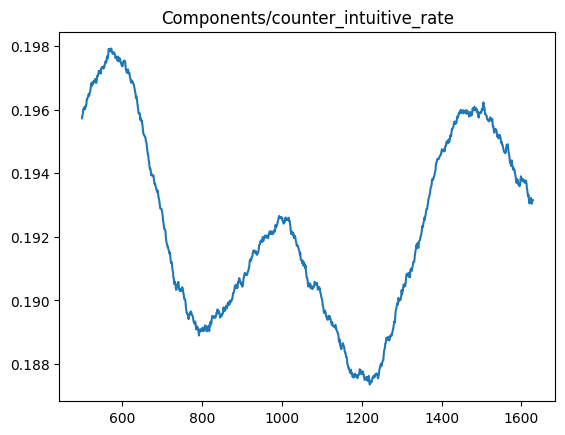

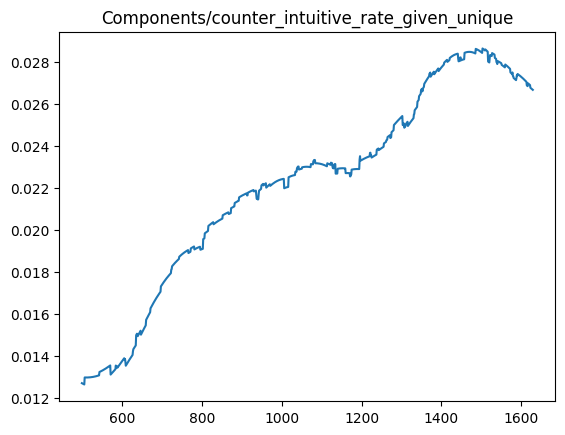

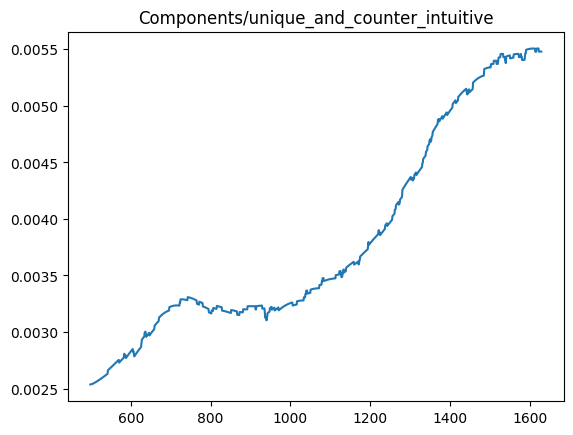

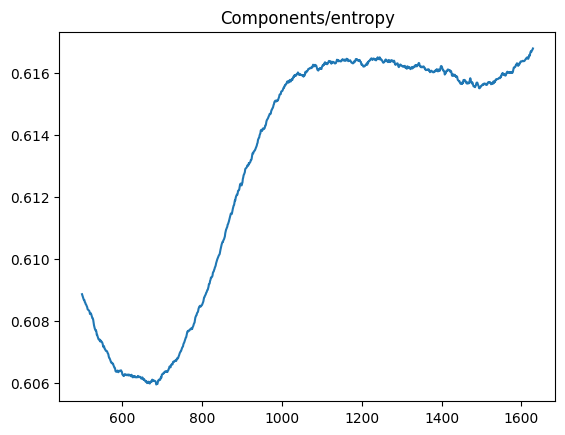

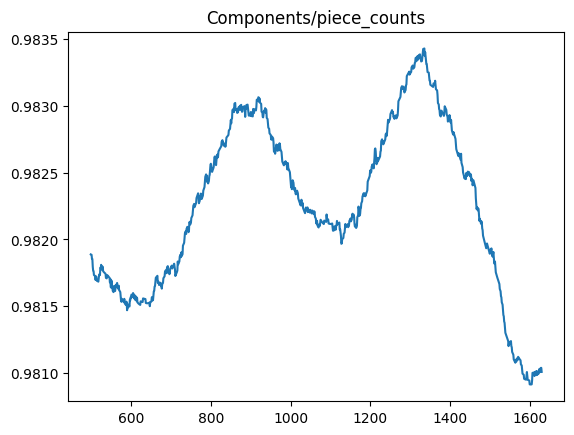

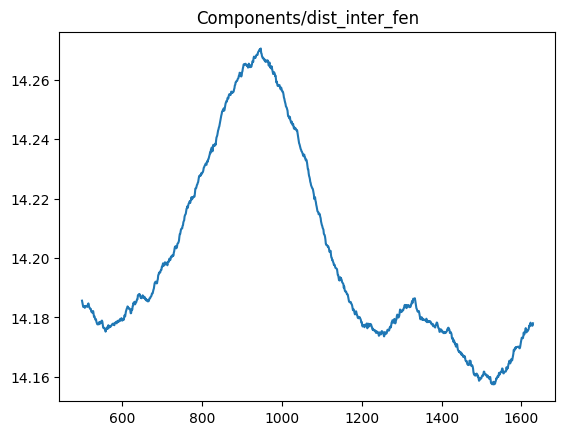

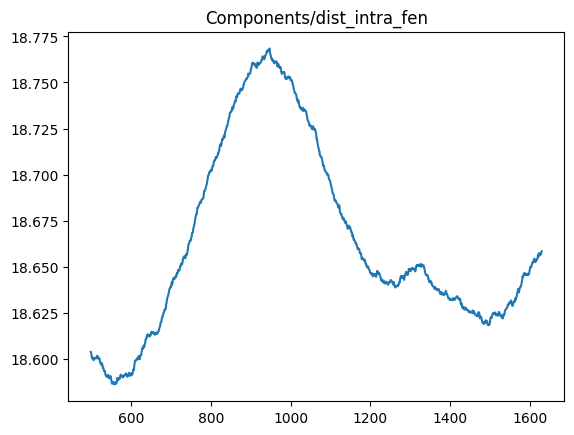

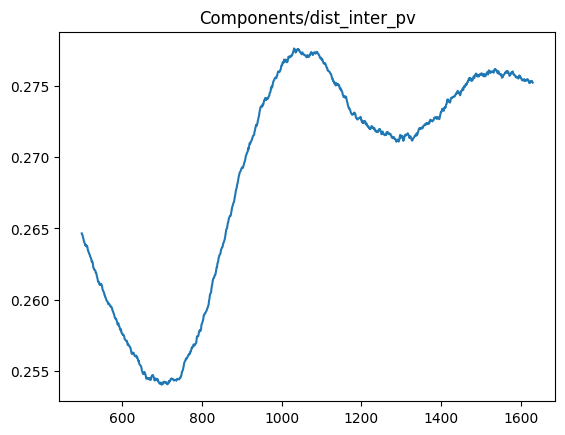

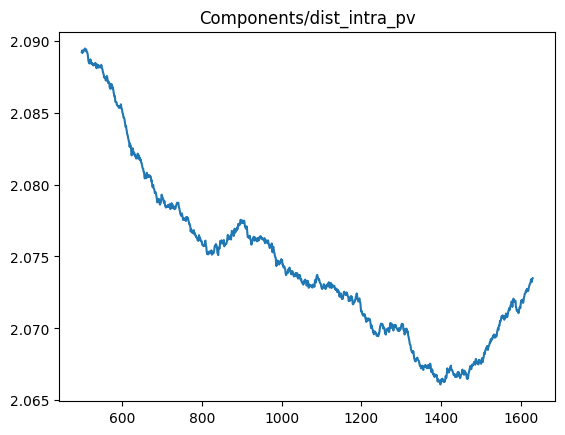

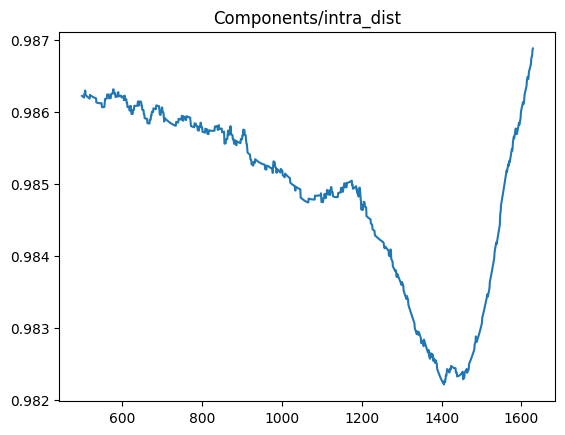

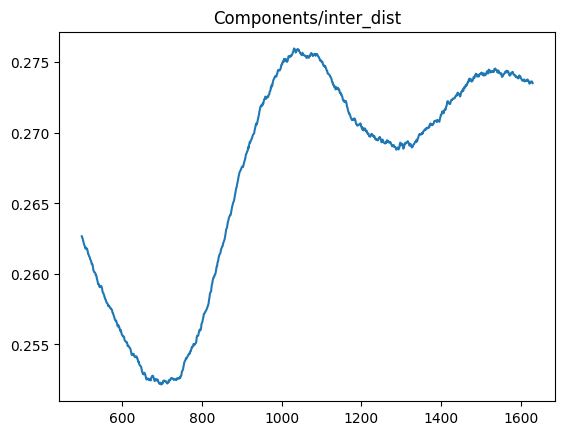

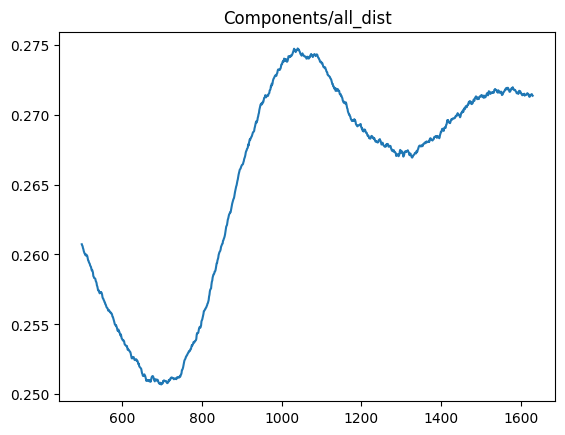

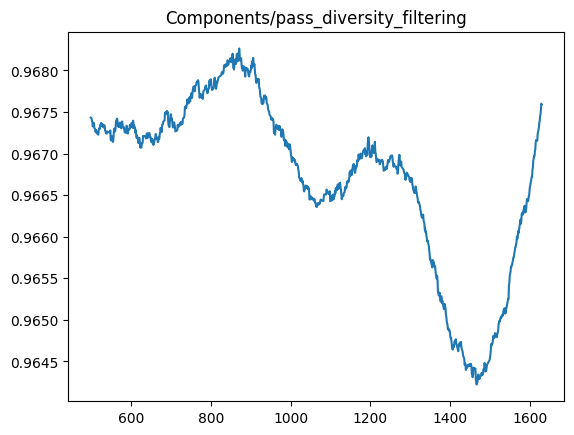

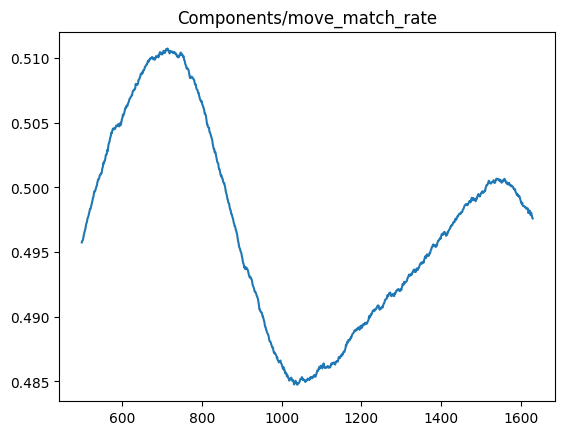

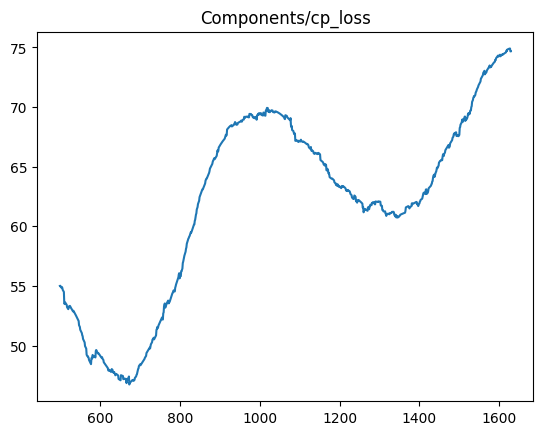

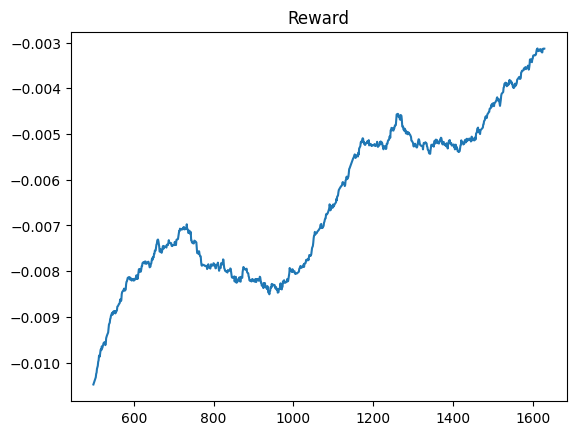

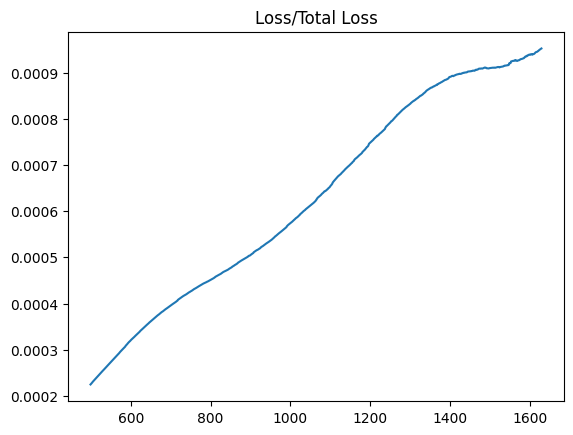

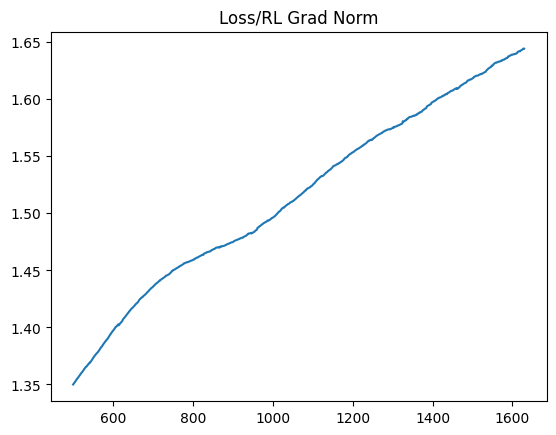

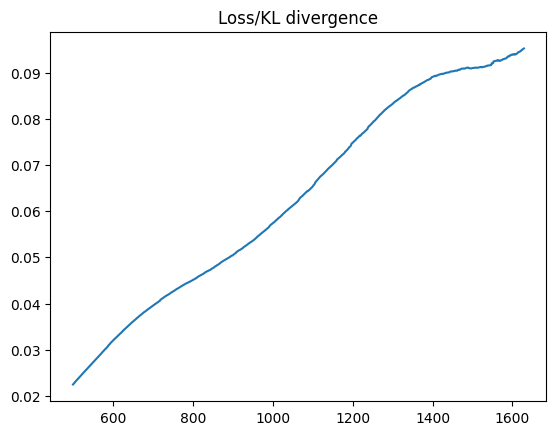

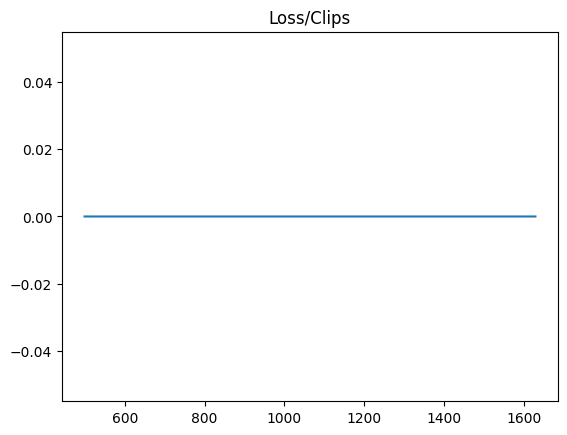

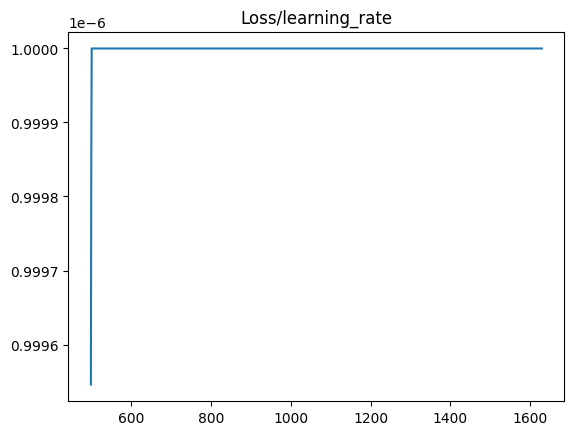

In [230]:
plot_all(df, window=500, type="rolling")